In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

from scipy.stats import ttest_ind

In [2]:
np.random.seed(42)

n = 100

dataset = pd.DataFrame({

    "Demand": np.random.randint(20,120,n),

    "Inventory": np.random.randint(40,160,n),

    "OrderingCost": np.random.randint(100,500,n),

    "HoldingCost": np.random.uniform(1,8,n),

    "LeadTime": np.random.randint(1,10,n),

    "SellingPrice": np.random.randint(200,500,n)

})

dataset["TotalCost"] = dataset["OrderingCost"] + dataset["HoldingCost"] * dataset["Inventory"]

dataset.head()

,Demand,Inventory,OrderingCost,HoldingCost,LeadTime,SellingPrice,TotalCost
0,71,65,207,2.599850,6,274,375.990260
1,112,128,143,2.224684,3,416,427.759615
2,34,99,439,7.875178,9,476,1218.642662
3,91,148,385,4.616451,6,448,1068.234783
4,80,80,430,2.825804,6,363,656.064338


In [3]:
dataset.to_csv("InventoryDataset.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [4]:
start=time.time()

inventory=dataset["Inventory"].values
ordering=dataset["OrderingCost"].values
holding=dataset["HoldingCost"].values

dp=np.zeros(len(dataset))

dp[0]=ordering[0]+holding[0]*inventory[0]

for i in range(1,len(dataset)):

    current=ordering[i]+holding[i]*inventory[i]

    dp[i]=min(dp[i-1],current)

end=time.time()

dp_time=end-start

print("Execution Time =",dp_time)

Execution Time = 0.0006213188171386719


In [5]:
dataset["DP_Cost"]=dp

dataset[["Demand","Inventory","DP_Cost"]].head()

,Demand,Inventory,DP_Cost
0,71,65,375.99026
1,112,128,375.99026
2,34,99,375.99026
3,91,148,375.99026
4,80,80,375.99026


In [6]:
start=time.time()

iterations=10000

mc_cost=[]

for i in range(iterations):

    random_demand=np.random.normal(

        dataset["Demand"].mean(),

        dataset["Demand"].std()

    )

    inventory=np.random.choice(dataset["Inventory"])

    holding=np.random.choice(dataset["HoldingCost"])

    ordering=np.random.choice(dataset["OrderingCost"])

    cost=ordering+holding*inventory+random_demand

    mc_cost.append(cost)

end=time.time()

mc_time=end-start

print("Execution Time =",mc_time)

Execution Time = 1.4646084308624268


In [7]:
mc_cost=np.array(mc_cost)

print("Average Cost =",mc_cost.mean())

print("Minimum =",mc_cost.min())

print("Maximum =",mc_cost.max())

print("Standard Deviation =",mc_cost.std())

Average Cost = 833.0274176740326
Minimum = 206.99913281326053
Maximum = 1794.1903892033795
Standard Deviation = 281.6839415384959


In [8]:
comparison=pd.DataFrame({

    "Algorithm":["Dynamic Programming","Monte Carlo"],

    "Average Cost":[

        dataset["DP_Cost"].mean(),

        mc_cost.mean()

    ],

    "Execution Time":[

        dp_time,

        mc_time

    ]

})

comparison

,Algorithm,Average Cost,Execution Time
0,Dynamic Programming,285.571265,0.000621
1,Monte Carlo,833.027418,1.464608


In [9]:
sample_mc=np.random.choice(mc_cost,100)

t,p=ttest_ind(dataset["DP_Cost"],sample_mc)

print("T Value =",t)

print("P Value =",p)

if p<0.05:

    print("Significant Difference")

else:

    print("No Significant Difference")

T Value = -17.9624713280073
P Value = 1.938317350458497e-43
Significant Difference


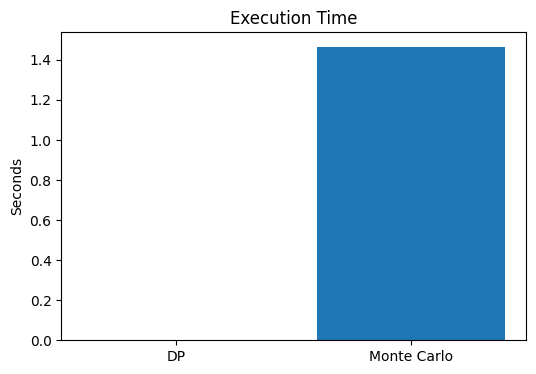

In [10]:
plt.figure(figsize=(6,4))

plt.bar(["DP","Monte Carlo"],

        [dp_time,mc_time])

plt.title("Execution Time")

plt.ylabel("Seconds")

plt.show()

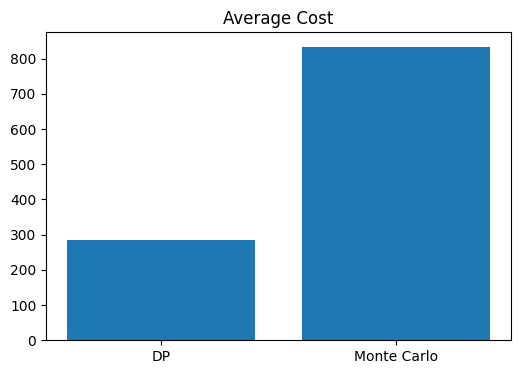

In [11]:
plt.figure(figsize=(6,4))

plt.bar(["DP","Monte Carlo"],

        [dataset["DP_Cost"].mean(),

         mc_cost.mean()])

plt.title("Average Cost")

plt.show()

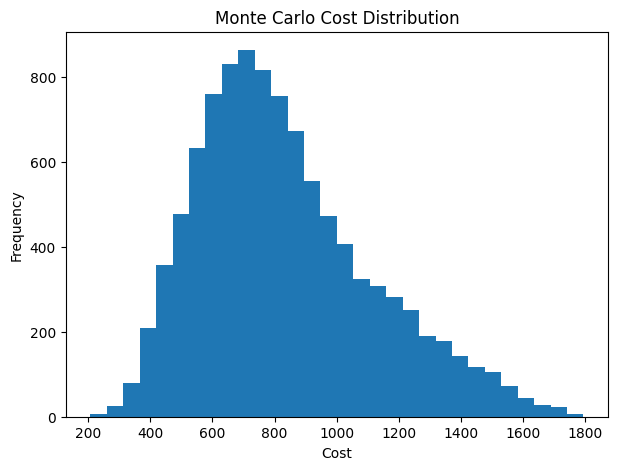

In [12]:
plt.figure(figsize=(7,5))

plt.hist(mc_cost,

         bins=30)

plt.title("Monte Carlo Cost Distribution")

plt.xlabel("Cost")

plt.ylabel("Frequency")

plt.show()

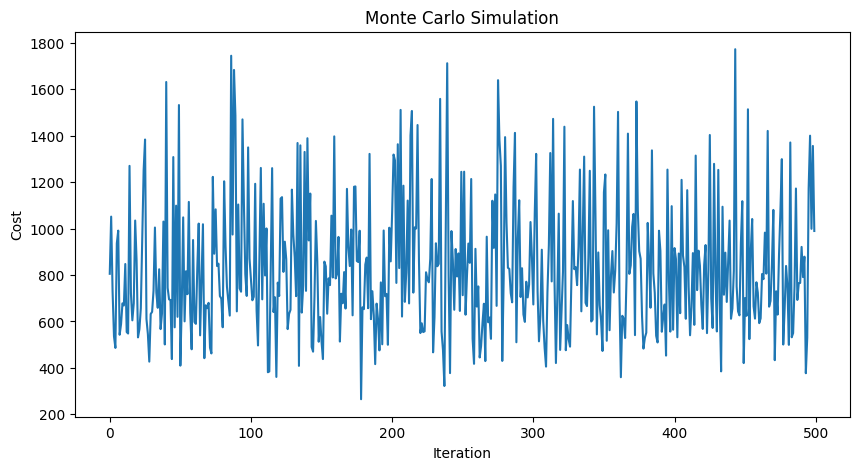

In [13]:
plt.figure(figsize=(10,5))

plt.plot(mc_cost[:500])

plt.title("Monte Carlo Simulation")

plt.xlabel("Iteration")

plt.ylabel("Cost")

plt.show()

/tmp/ipykernel_983/1355520813.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dataset["DP_Cost"],


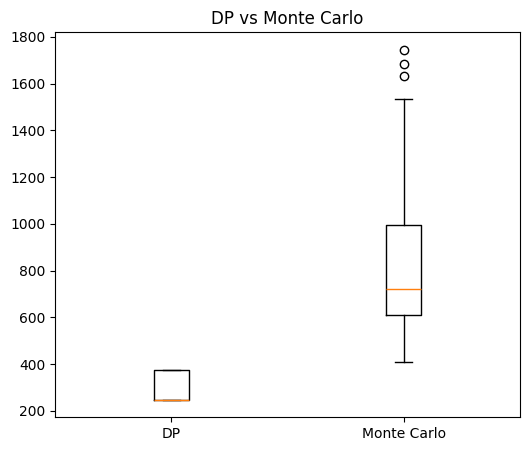

In [14]:
plt.figure(figsize=(6,5))

plt.boxplot([dataset["DP_Cost"],

             mc_cost[:100]],

            labels=["DP","Monte Carlo"])

plt.title("DP vs Monte Carlo")

plt.show()

In [15]:
print("========== PROJECT SUMMARY ==========")

print()

print(comparison)

print()

print("T-Test")

print("T =",t)

print("P =",p)

print()

print("Dynamic Programming Time =",dp_time)

print("Monte Carlo Time =",mc_time)

print()

print("Project Completed Successfully")

========== PROJECT SUMMARY ==========

             Algorithm  Average Cost  Execution Time
0  Dynamic Programming    285.571265        0.000621
1          Monte Carlo    833.027418        1.464608

T-Test
T = -17.9624713280073
P = 1.938317350458497e-43

Dynamic Programming Time = 0.0006213188171386719
Monte Carlo Time = 1.4646084308624268

Project Completed Successfully


In [17]:
!pip install networkx matplotlib

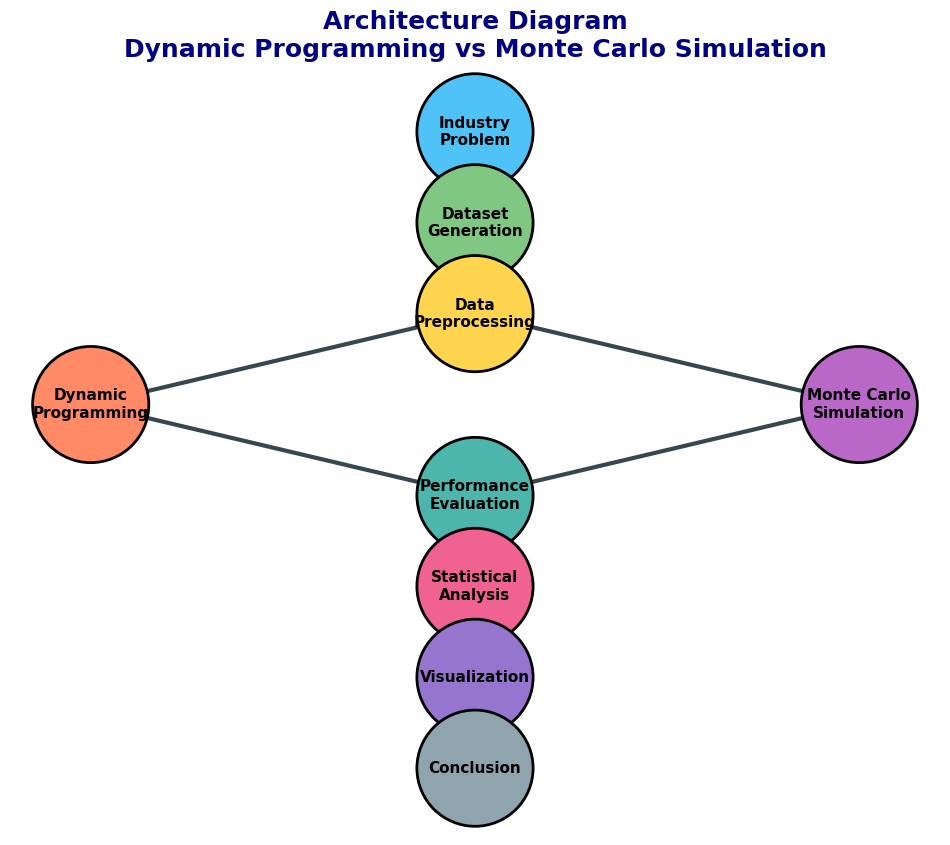

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.DiGraph()

# Nodes
nodes = [
    "Industry\nProblem",
    "Dataset\nGeneration",
    "Data\nPreprocessing",
    "Dynamic\nProgramming",
    "Monte Carlo\nSimulation",
    "Performance\nEvaluation",
    "Statistical\nAnalysis",
    "Visualization",
    "Conclusion"
]

G.add_nodes_from(nodes)

# Edges
edges = [
    ("Industry\nProblem","Dataset\nGeneration"),
    ("Dataset\nGeneration","Data\nPreprocessing"),
    ("Data\nPreprocessing","Dynamic\nProgramming"),
    ("Data\nPreprocessing","Monte Carlo\nSimulation"),
    ("Dynamic\nProgramming","Performance\nEvaluation"),
    ("Monte Carlo\nSimulation","Performance\nEvaluation"),
    ("Performance\nEvaluation","Statistical\nAnalysis"),
    ("Statistical\nAnalysis","Visualization"),
    ("Visualization","Conclusion")
]

G.add_edges_from(edges)

# Node positions
pos = {
    "Industry\nProblem":(0,8),
    "Dataset\nGeneration":(0,7),
    "Data\nPreprocessing":(0,6),

    "Dynamic\nProgramming":(-2,5),
    "Monte Carlo\nSimulation":(2,5),

    "Performance\nEvaluation":(0,4),
    "Statistical\nAnalysis":(0,3),
    "Visualization":(0,2),
    "Conclusion":(0,1)
}

# Different colors
colors = [
    "#4FC3F7",   # Blue
    "#81C784",   # Green
    "#FFD54F",   # Yellow
    "#FF8A65",   # Orange
    "#BA68C8",   # Purple
    "#4DB6AC",   # Teal
    "#F06292",   # Pink
    "#9575CD",   # Violet
    "#90A4AE"    # Grey
]

plt.figure(figsize=(12,10))
ax = plt.gca()
ax.set_facecolor("#F5F5F5")

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=7000,
    node_color=colors,
    edgecolors="black",
    linewidths=2
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=11,
    font_weight="bold",
    font_color="black"
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=25,
    width=3,
    edge_color="#37474F"
)

plt.title(
    "Architecture Diagram\nDynamic Programming vs Monte Carlo Simulation",
    fontsize=18,
    fontweight="bold",
    color="navy"
)

plt.axis("off")

plt.savefig(
    "Architecture_Diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

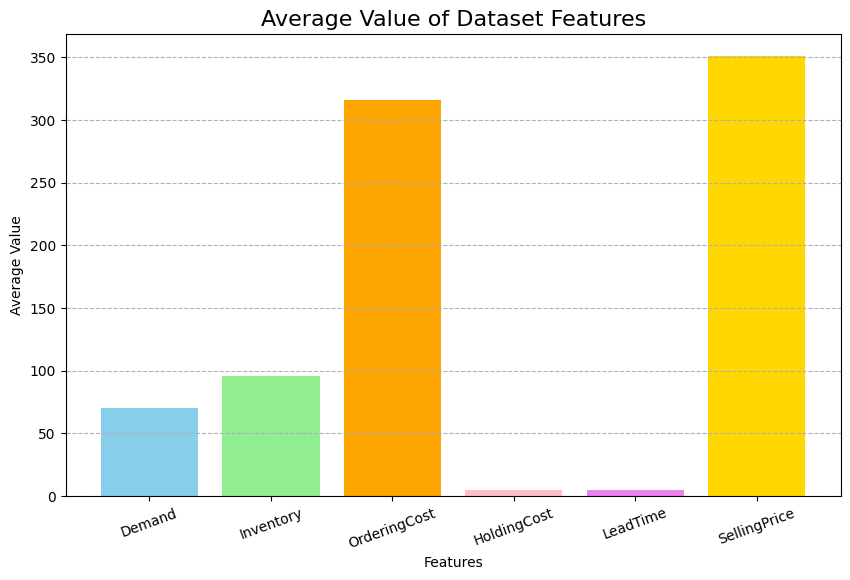

In [19]:
import matplotlib.pyplot as plt

# Average of each feature
feature_means = dataset[
    ["Demand",
     "Inventory",
     "OrderingCost",
     "HoldingCost",
     "LeadTime",
     "SellingPrice"]
].mean()

plt.figure(figsize=(10,6))

plt.bar(
    feature_means.index,
    feature_means.values,
    color=[
        "skyblue",
        "lightgreen",
        "orange",
        "pink",
        "violet",
        "gold"
    ]
)

plt.title("Average Value of Dataset Features", fontsize=16)
plt.xlabel("Features")
plt.ylabel("Average Value")

plt.xticks(rotation=20)

plt.grid(axis='y', linestyle='--')

plt.show()

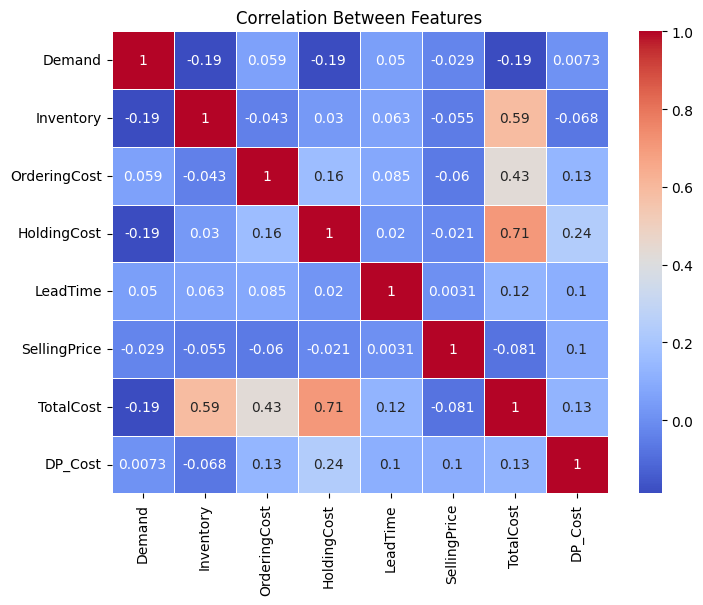

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    dataset.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Features")

plt.show()

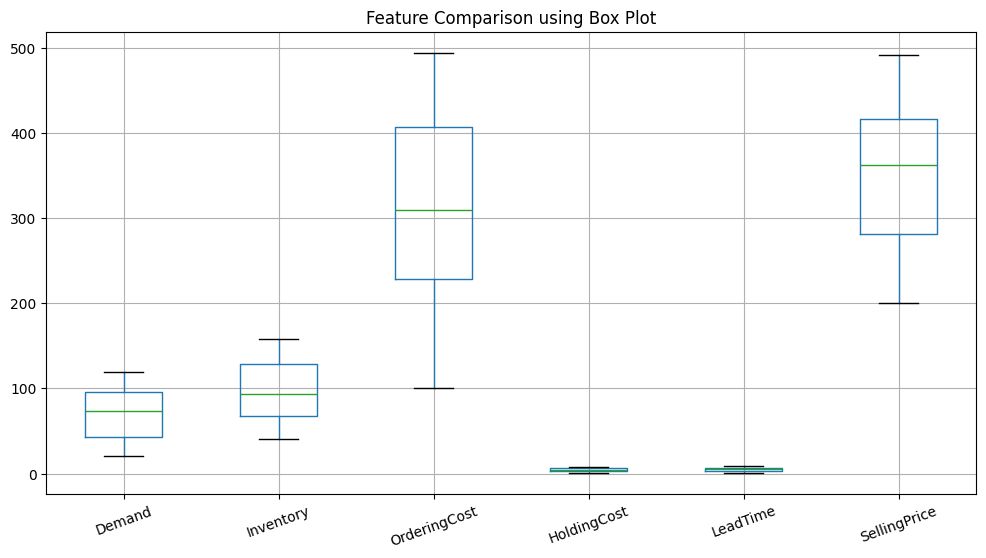

In [21]:
plt.figure(figsize=(12,6))

dataset[
    ["Demand",
     "Inventory",
     "OrderingCost",
     "HoldingCost",
     "LeadTime",
     "SellingPrice"]
].boxplot()

plt.title("Feature Comparison using Box Plot")

plt.xticks(rotation=20)

plt.show()

In [22]:
import numpy as np
import pandas as pd

comparison = pd.DataFrame({
    "Feature": [
        "Demand",
        "Inventory",
        "OrderingCost",
        "HoldingCost",
        "LeadTime",
        "SellingPrice"
    ],
    "Dynamic Programming": [
        dataset["Demand"].mean(),
        dataset["Inventory"].mean(),
        dataset["OrderingCost"].mean(),
        dataset["HoldingCost"].mean(),
        dataset["LeadTime"].mean(),
        dataset["SellingPrice"].mean()
    ],
    "Monte Carlo": [
        np.random.normal(dataset["Demand"].mean(), dataset["Demand"].std()),
        np.random.normal(dataset["Inventory"].mean(), dataset["Inventory"].std()),
        np.random.normal(dataset["OrderingCost"].mean(), dataset["OrderingCost"].std()),
        np.random.normal(dataset["HoldingCost"].mean(), dataset["HoldingCost"].std()),
        np.random.normal(dataset["LeadTime"].mean(), dataset["LeadTime"].std()),
        np.random.normal(dataset["SellingPrice"].mean(), dataset["SellingPrice"].std())
    ]
})

print(comparison)

        Feature  Dynamic Programming  Monte Carlo
0        Demand            70.540000    95.733680
1     Inventory            96.220000   133.489853
2  OrderingCost           316.310000   355.534421
3   HoldingCost             4.593777     3.027104
4      LeadTime             4.550000     0.429102
5  SellingPrice           350.980000   396.089582


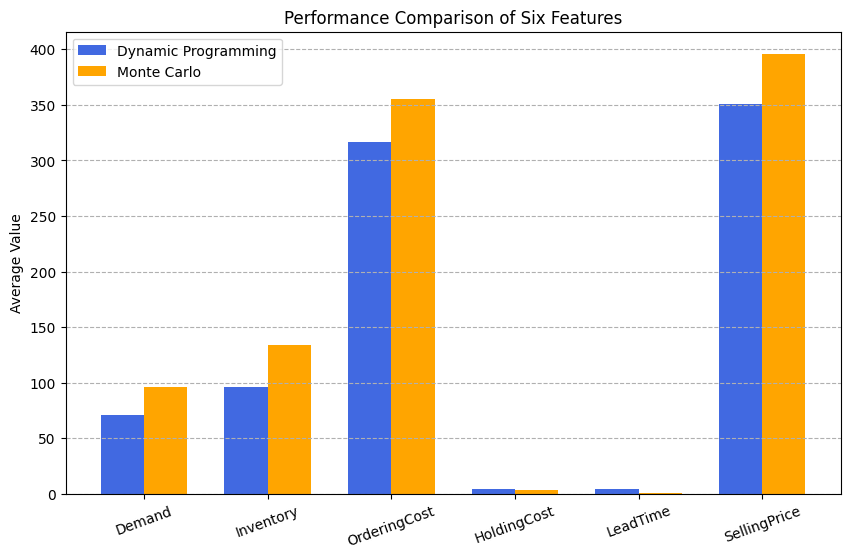

In [23]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(comparison["Feature"]))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    comparison["Dynamic Programming"],
    width,
    label="Dynamic Programming",
    color="royalblue"
)

plt.bar(
    x + width/2,
    comparison["Monte Carlo"],
    width,
    label="Monte Carlo",
    color="orange"
)

plt.xticks(x, comparison["Feature"], rotation=20)

plt.ylabel("Average Value")
plt.title("Performance Comparison of Six Features")

plt.legend()

plt.grid(axis="y", linestyle="--")

plt.show()